In [1]:
"""
Baseline ResNet-50 for Thoracic Disease Classification
Based on: El-Fiky et al. (2021) - Multi-Label Transfer Learning

This notebook implements the baseline ResNet-50 model using transfer learning
methodology from the paper to achieve comparable performance (AUC: 0.911, F1: 0.66)
"""
import numpy as np
import pandas as pd
import os
import glob
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, hamming_loss, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================================
# CBAM ATTENTION MODULE IMPLEMENTATION
# ============================================================================

class ChannelAttention(layers.Layer):
    """Channel Attention Module"""
    def __init__(self, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.ratio = ratio
    
    def build(self, input_shape):
        channels = input_shape[-1]
        self.shared_dense_one = layers.Dense(
            channels // self.ratio,
            activation='relu',
            kernel_initializer='he_normal',
            use_bias=True
        )
        self.shared_dense_two = layers.Dense(
            channels,
            kernel_initializer='he_normal',
            use_bias=True
        )
        super(ChannelAttention, self).build(input_shape)
    
    def call(self, inputs):
        # Average pooling
        avg_pool = layers.GlobalAveragePooling2D()(inputs)
        avg_pool = layers.Reshape((1, 1, inputs.shape[-1]))(avg_pool)
        avg_pool = self.shared_dense_one(avg_pool)
        avg_pool = self.shared_dense_two(avg_pool)
        
        # Max pooling
        max_pool = layers.GlobalMaxPooling2D()(inputs)
        max_pool = layers.Reshape((1, 1, inputs.shape[-1]))(max_pool)
        max_pool = self.shared_dense_one(max_pool)
        max_pool = self.shared_dense_two(max_pool)
        
        # Combine and apply sigmoid
        channel_attention = layers.Add()([avg_pool, max_pool])
        channel_attention = layers.Activation('sigmoid')(channel_attention)
        
        return layers.Multiply()([inputs, channel_attention])
    
    def get_config(self):
        config = super(ChannelAttention, self).get_config()
        config.update({'ratio': self.ratio})
        return config


class SpatialAttention(layers.Layer):
    """Spatial Attention Module"""
    def __init__(self, kernel_size=7, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size
    
    def build(self, input_shape):
        self.conv = layers.Conv2D(
            filters=1,
            kernel_size=self.kernel_size,
            strides=1,
            padding='same',
            activation='sigmoid',
            kernel_initializer='he_normal',
            use_bias=False
        )
        super(SpatialAttention, self).build(input_shape)
    
    def call(self, inputs):
        # Average pooling along channel axis
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        
        # Max pooling along channel axis
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        
        # Concatenate
        concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
        
        # Apply convolution
        spatial_attention = self.conv(concat)
        
        return layers.Multiply()([inputs, spatial_attention])
    
    def get_config(self):
        config = super(SpatialAttention, self).get_config()
        config.update({'kernel_size': self.kernel_size})
        return config


class CBAM(layers.Layer):
    """Convolutional Block Attention Module (CBAM)"""
    def __init__(self, ratio=8, kernel_size=7, **kwargs):
        super(CBAM, self).__init__(**kwargs)
        self.channel_attention = ChannelAttention(ratio=ratio)
        self.spatial_attention = SpatialAttention(kernel_size=kernel_size)
    
    def call(self, inputs):
        x = self.channel_attention(inputs)
        x = self.spatial_attention(x)
        return x
    
    def get_config(self):
        config = super(CBAM, self).get_config()
        return config

In [3]:
# Cell 2: Dataset Configuration and Loading
BASE_DIR = "./dataset_pneumothorax/"
CSV_PATH = os.path.join(BASE_DIR, "pneumothorax.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "images")

print(f"Loading balanced Pneumothorax dataset...")

# Load the balanced dataset CSV
try:
    df = pd.read_csv(CSV_PATH)
    print(f"✓ Loaded CSV with {len(df):,} total images")
except Exception as e:
    print(f"✗ Error reading CSV {CSV_PATH}: {e}")
    exit(1)

# Display CSV structure
print(f"\n=== Dataset Structure ===")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df.head(3))

# Use Binary_Label column (already created by dataset.py)
if 'Binary_Label' in df.columns:
    df['binary_label'] = df['Binary_Label']
elif 'Pneumothorax' in df.columns:
    df['binary_label'] = df['Pneumothorax'].astype(int)
else:
    print("✗ Could not find Pneumothorax labels")
    exit(1)

# Create full image paths
df['path'] = df['Image_Index'].apply(lambda x: os.path.join(IMAGE_DIR, x))

# Verify images exist
df['exists'] = df['path'].apply(os.path.exists)
missing_count = (~df['exists']).sum()

if missing_count > 0:
    print(f"\n⚠ Warning: {missing_count} images not found")
    df = df[df['exists']].copy()

df = df.drop(columns=['exists'])
balanced_df = df.copy()

print(f"\n=== Final Dataset Summary ===")
print(f"Total images: {len(df):,}")
print(f"Pneumothorax (Positive): {df['binary_label'].sum():,} ({df['binary_label'].sum()/len(df)*100:.1f}%)")
print(f"No Pneumothorax (Negative): {(len(df) - df['binary_label'].sum()):,} ({(len(df) - df['binary_label'].sum())/len(df)*100:.1f}%)")
print(f"Balance ratio: 1:1")
print(f"\nDataset is ready for training!")

Loading balanced Pneumothorax dataset...
✓ Loaded CSV with 10,604 total images

=== Dataset Structure ===
Columns: ['Image_Index', 'Finding_Labels', 'Pneumothorax', 'Path', 'Binary_Label']

First 3 rows:
        Image_Index                      Finding_Labels  Pneumothorax  \
0  00001974_002.png           Infiltration|Pneumothorax             1   
1  00012620_013.png  Atelectasis|Consolidation|Effusion             0   
2  00014870_000.png                  Consolidation|Mass             0   

                      Path  Binary_Label  
0  images\00001974_002.png             1  
1  images\00012620_013.png             0  
2  images\00014870_000.png             0  

=== Final Dataset Summary ===
Total images: 10,604
Pneumothorax (Positive): 5,302 (50.0%)
No Pneumothorax (Negative): 5,302 (50.0%)
Balance ratio: 1:1

Dataset is ready for training!


In [4]:
# Cell 4: Dataset Splitting with Stratification
# Path already exists from Cell 2, just use balanced_df directly
print(f"Dataset ready for splitting: {len(balanced_df)} samples")

# Stratified train-validation-test split (80/10/10)
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.2,
    random_state=42,
    stratify=balanced_df['binary_label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['binary_label']
)

print(f"\n=== Dataset Splits (Stratified) ===")
print(f"Training set: {len(train_df):,} samples")
print(f"  Positive: {train_df['binary_label'].sum():,} ({train_df['binary_label'].sum()/len(train_df)*100:.1f}%)")
print(f"  Negative: {len(train_df) - train_df['binary_label'].sum():,} ({(len(train_df) - train_df['binary_label'].sum())/len(train_df)*100:.1f}%)")

print(f"\nValidation set: {len(val_df):,} samples")
print(f"  Positive: {val_df['binary_label'].sum():,} ({val_df['binary_label'].sum()/len(val_df)*100:.1f}%)")
print(f"  Negative: {len(val_df) - val_df['binary_label'].sum():,} ({(len(val_df) - val_df['binary_label'].sum())/len(val_df)*100:.1f}%)")

print(f"\nTest set: {len(test_df):,} samples")
print(f"  Positive: {test_df['binary_label'].sum():,} ({test_df['binary_label'].sum()/len(test_df)*100:.1f}%)")
print(f"  Negative: {len(test_df) - test_df['binary_label'].sum():,} ({(len(test_df) - test_df['binary_label'].sum())/len(test_df)*100:.1f}%)")

# Save splits
os.makedirs('./output', exist_ok=True)
test_df.to_csv('./output/pneumothorax_test_set.csv', index=False)
print("\n✓ Test set saved for final evaluation")

Dataset ready for splitting: 10604 samples

=== Dataset Splits (Stratified) ===
Training set: 8,483 samples
  Positive: 4,242 (50.0%)
  Negative: 4,241 (50.0%)

Validation set: 1,060 samples
  Positive: 530 (50.0%)
  Negative: 530 (50.0%)

Test set: 1,061 samples
  Positive: 530 (50.0%)
  Negative: 531 (50.0%)

✓ Test set saved for final evaluation


In [5]:
# ============================================================================
# CONFIGURATION
# ============================================================================

IMAGE_SIZE = 224
BATCH_SIZE = 32

print(f"Configuration:")
print(f"  Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")

Configuration:
  Image Size: 224x224
  Batch Size: 32


In [6]:
# ============================================================================
# TEST DATASET PIPELINE
# ============================================================================

def create_test_dataset(df, batch_size):
    """Create test dataset pipeline (no augmentation)"""
    
    def load_and_preprocess(image_path, label):
        # Load image
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
        
        # Normalize using ResNet50V2 preprocessing (same as training)
        img = tf.keras.applications.resnet_v2.preprocess_input(img)
        return img, label
    
    # Create dataset
    image_paths = df['path'].values
    labels = df['binary_label'].values.astype(np.float32)
    
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Create test dataset
print("Creating test dataset pipeline...")
test_dataset = create_test_dataset(test_df, BATCH_SIZE)

print(f"✅ Test dataset created:")
print(f"  Test samples: {len(test_df)}")
print(f"  Test batches: {len(test_dataset)}")
print(f"  Positive: {test_df['binary_label'].sum()}")
print(f"  Negative: {len(test_df) - test_df['binary_label'].sum()}")

Creating test dataset pipeline...
✅ Test dataset created:
  Test samples: 1061
  Test batches: 34
  Positive: 530
  Negative: 531


In [7]:
# ============================================================================
# LOAD TRAINED MODEL
# ============================================================================

MODEL_PATH = "./output/resnet50_cbam_best.keras"

print(f"\n{'='*80}")
print(f"LOADING MODEL FOR EVALUATION")
print(f"{'='*80}")
print(f"Model path: {MODEL_PATH}\n")

# Check if model exists
if not os.path.exists(MODEL_PATH):
    print(f"❌ ERROR: Model file not found at {MODEL_PATH}")
    print(f"   Please check the file path and try again.")
else:
    print(f"✅ Model file found!")
    
    # Load model
    try:
        model = keras.models.load_model(MODEL_PATH, custom_objects={'CBAM': CBAM})
        print(f"✅ Model loaded successfully!")
        
        # Model summary
        print(f"\n📊 Model Architecture:")
        print(f"  Total parameters: {model.count_params():,}")
        
        trainable_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
        print(f"  Trainable parameters: {trainable_params:,}")
        
        # Model input/output shapes
        print(f"\n📐 Model I/O:")
        print(f"  Input shape: {model.input_shape}")
        print(f"  Output shape: {model.output_shape}")
        
    except Exception as e:
        print(f"❌ ERROR loading model: {e}")
        raise


LOADING MODEL FOR EVALUATION
Model path: ./output/resnet50_cbam_best.keras

✅ Model file found!
✅ Model loaded successfully!

📊 Model Architecture:
  Total parameters: 24,617,827
  Trainable parameters: 24,572,387

📐 Model I/O:
  Input shape: (None, 224, 224, 3)
  Output shape: (None, 1)


In [14]:
# ============================================================================
# GENERATE PREDICTIONS ON TEST SET
# ============================================================================

print(f"\n{'='*80}")
print(f"GENERATING PREDICTIONS ON TEST SET")
print(f"{'='*80}\n")

# Generate predictions
print("Running inference on test set...")
test_predictions = model.predict(test_dataset, verbose=1)

# Process predictions
y_true = test_df['binary_label'].values
y_pred_probs = test_predictions.flatten()  # Predicted probabilities
y_pred = (y_pred_probs > 0.5).astype(int)  # Binary predictions (threshold=0.5)

print(f"\n✅ Predictions generated!")
print(f"  True labels shape: {y_true.shape}")
print(f"  Predicted probabilities shape: {y_pred_probs.shape}")
print(f"  Binary predictions shape: {y_pred.shape}")
print(f"\n  Unique true labels: {np.unique(y_true)}")
print(f"  Unique predictions: {np.unique(y_pred)}")
print(f"  Probability range: [{y_pred_probs.min():.4f}, {y_pred_probs.max():.4f}]")


GENERATING PREDICTIONS ON TEST SET

Running inference on test set...
34/34 [==============================] - 3s 77ms/step

✅ Predictions generated!
  True labels shape: (1061,)
  Predicted probabilities shape: (1061,)
  Binary predictions shape: (1061,)

  Unique true labels: [0 1]
  Unique predictions: [0 1]
  Probability range: [0.0005, 0.9990]


In [15]:
# ============================================================================
# COMPREHENSIVE TEST SET EVALUATION
# ============================================================================

from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

print(f"\n{'='*80}")
print(f"TEST SET EVALUATION")
print(f"{'='*80}\n")

# ============================================================================
# 1. AUC-ROC SCORE
# ============================================================================
auc_score = roc_auc_score(y_true, y_pred_probs)

# ============================================================================
# 2. CONFUSION MATRIX
# ============================================================================
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# ============================================================================
# 3. CALCULATE ALL METRICS
# ============================================================================

# Basic metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)  # Same as sensitivity
f1 = f1_score(y_true, y_pred)

# Clinical metrics
sensitivity = tp / (tp + fn)  # True Positive Rate (Recall)
specificity = tn / (tn + fp)  # True Negative Rate

# Positive/Negative Predictive Values
ppv = tp / (tp + fp)  # Precision
npv = tn / (tn + fn)

# ============================================================================
# DISPLAY RESULTS
# ============================================================================

print(f"📊 DISCRIMINATION ABILITY")
print(f"{'='*80}")
print(f"  AUC-ROC Score:        {auc_score:.4f}")
print(f"")

print(f"🎯 CLASSIFICATION METRICS")
print(f"{'='*80}")
print(f"  Accuracy:             {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision (PPV):      {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall (Sensitivity): {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score:             {f1:.4f}")
print(f"")

print(f"🏥 CLINICAL METRICS")
print(f"{'='*80}")
print(f"  Sensitivity (TPR):    {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"  Specificity (TNR):    {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  Positive Predictive:  {ppv:.4f} ({ppv*100:.2f}%)")
print(f"  Negative Predictive:  {npv:.4f} ({npv*100:.2f}%)")
print(f"")

print(f"🔢 CONFUSION MATRIX")
print(f"{'='*80}")
print(f"                    Predicted")
print(f"                 Neg      Pos")
print(f"  Actual  Neg    {tn:4d}    {fp:4d}    (TN={tn}, FP={fp})")
print(f"          Pos    {fn:4d}    {tp:4d}    (FN={fn}, TP={tp})")
print(f"")
print(f"  True Negatives (TN):  {tn:4d} ✓ Correctly identified negative cases")
print(f"  False Positives (FP): {fp:4d} ✗ Incorrectly flagged as pneumothorax")
print(f"  False Negatives (FN): {fn:4d} ✗ Missed pneumothorax cases")
print(f"  True Positives (TP):  {tp:4d} ✓ Correctly detected pneumothorax")
print(f"")

print(f"📈 DETAILED BREAKDOWN")
print(f"{'='*80}")
print(f"  Total test samples:   {len(y_true)}")
print(f"  Positive cases:       {y_true.sum()} ({y_true.sum()/len(y_true)*100:.1f}%)")
print(f"  Negative cases:       {len(y_true) - y_true.sum()} ({(len(y_true) - y_true.sum())/len(y_true)*100:.1f}%)")
print(f"")
print(f"  Correctly classified: {tp + tn} ({(tp + tn)/len(y_true)*100:.1f}%)")
print(f"  Misclassified:        {fp + fn} ({(fp + fn)/len(y_true)*100:.1f}%)")
print(f"")

print(f"🎯 CLINICAL INTERPRETATION")
print(f"{'='*80}")
print(f"  • Model catches {sensitivity*100:.1f}% of pneumothorax cases")
print(f"  • Model correctly clears {specificity*100:.1f}% of healthy patients")
print(f"  • {ppv*100:.1f}% of flagged cases are true pneumothorax")
print(f"  • {npv*100:.1f}% of cleared cases are truly negative")
print(f"  • Misses {fn} out of {tp+fn} pneumothorax cases ({fn/(tp+fn)*100:.1f}%)")
print(f"  • False alarm rate: {fp/(tn+fp)*100:.1f}% ({fp} out of {tn+fp} negative cases)")

print(f"\n{'='*80}")


TEST SET EVALUATION

📊 DISCRIMINATION ABILITY
  AUC-ROC Score:        0.8652

🎯 CLASSIFICATION METRICS
  Accuracy:             0.7861 (78.61%)
  Precision (PPV):      0.8451 (84.51%)
  Recall (Sensitivity): 0.7000 (70.00%)
  F1-Score:             0.7657

🏥 CLINICAL METRICS
  Sensitivity (TPR):    0.7000 (70.00%)
  Specificity (TNR):    0.8719 (87.19%)
  Positive Predictive:  0.8451 (84.51%)
  Negative Predictive:  0.7444 (74.44%)

🔢 CONFUSION MATRIX
                    Predicted
                 Neg      Pos
  Actual  Neg     463      68    (TN=463, FP=68)
          Pos     159     371    (FN=159, TP=371)

  True Negatives (TN):   463 ✓ Correctly identified negative cases
  False Positives (FP):   68 ✗ Incorrectly flagged as pneumothorax
  False Negatives (FN):  159 ✗ Missed pneumothorax cases
  True Positives (TP):   371 ✓ Correctly detected pneumothorax

📈 DETAILED BREAKDOWN
  Total test samples:   1061
  Positive cases:       530 (50.0%)
  Negative cases:       531 (50.0%)

  Corre

In [10]:
# ============================================================================
# SKLEARN CLASSIFICATION REPORT
# ============================================================================

print(f"\n📋 CLASSIFICATION REPORT (sklearn)")
print(f"{'='*80}")
print(classification_report(
    y_true, 
    y_pred, 
    target_names=['No Pneumothorax', 'Pneumothorax'],
    digits=4
))


📋 CLASSIFICATION REPORT (sklearn)
                 precision    recall  f1-score   support

No Pneumothorax     0.7444    0.8719    0.8031       531
   Pneumothorax     0.8451    0.7000    0.7657       530

       accuracy                         0.7861      1061
      macro avg     0.7947    0.7860    0.7844      1061
   weighted avg     0.7947    0.7861    0.7844      1061



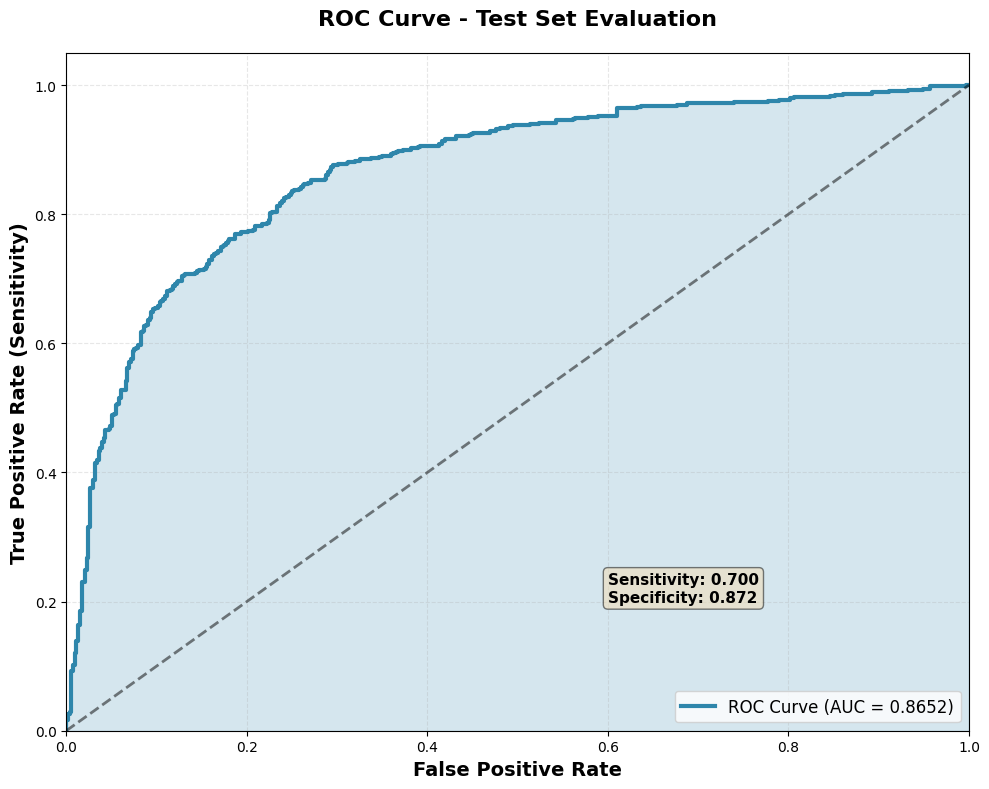

✅ ROC curve saved to: ./output/test_set_roc_curve.png


In [17]:
# ============================================================================
# ROC CURVE VISUALIZATION
# ============================================================================

from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='#2E86AB', linewidth=3, 
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5)
plt.fill_between(fpr, tpr, alpha=0.2, color='#2E86AB')

plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=14, fontweight='bold')
plt.title('ROC Curve - Test Set Evaluation', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Add annotations
plt.text(0.6, 0.2, f'Sensitivity: {sensitivity:.3f}\nSpecificity: {specificity:.3f}',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('./output/test_set_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ ROC curve saved to: ./output/test_set_roc_curve.png")

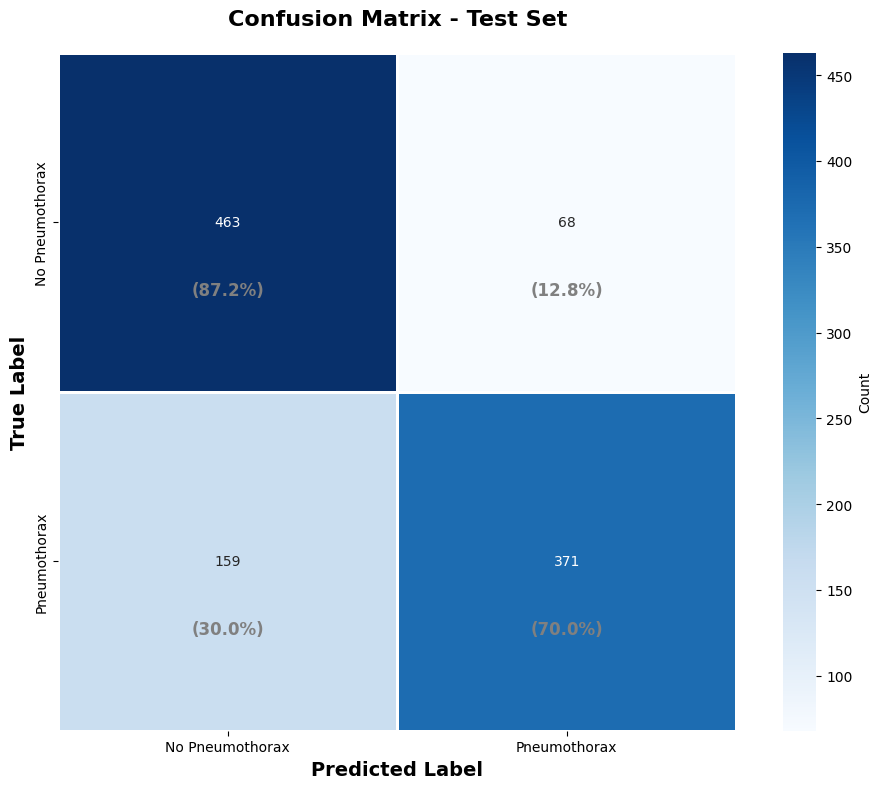

✅ Confusion matrix saved to: ./output/test_set_confusion_matrix.png


In [12]:
# ============================================================================
# CONFUSION MATRIX HEATMAP
# ============================================================================

plt.figure(figsize=(10, 8))

# Normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            cbar_kws={'label': 'Count'},
            xticklabels=['No Pneumothorax', 'Pneumothorax'],
            yticklabels=['No Pneumothorax', 'Pneumothorax'],
            linewidths=2, linecolor='white',
            square=True, cbar=True)

# Add percentages
for i in range(2):
    for j in range(2):
        plt.text(j+0.5, i+0.7, f'({cm_normalized[i, j]:.1%})',
                ha='center', va='center', 
                fontsize=12, color='gray', fontweight='bold')

plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.title('Confusion Matrix - Test Set', 
          fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('./output/test_set_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Confusion matrix saved to: ./output/test_set_confusion_matrix.png")

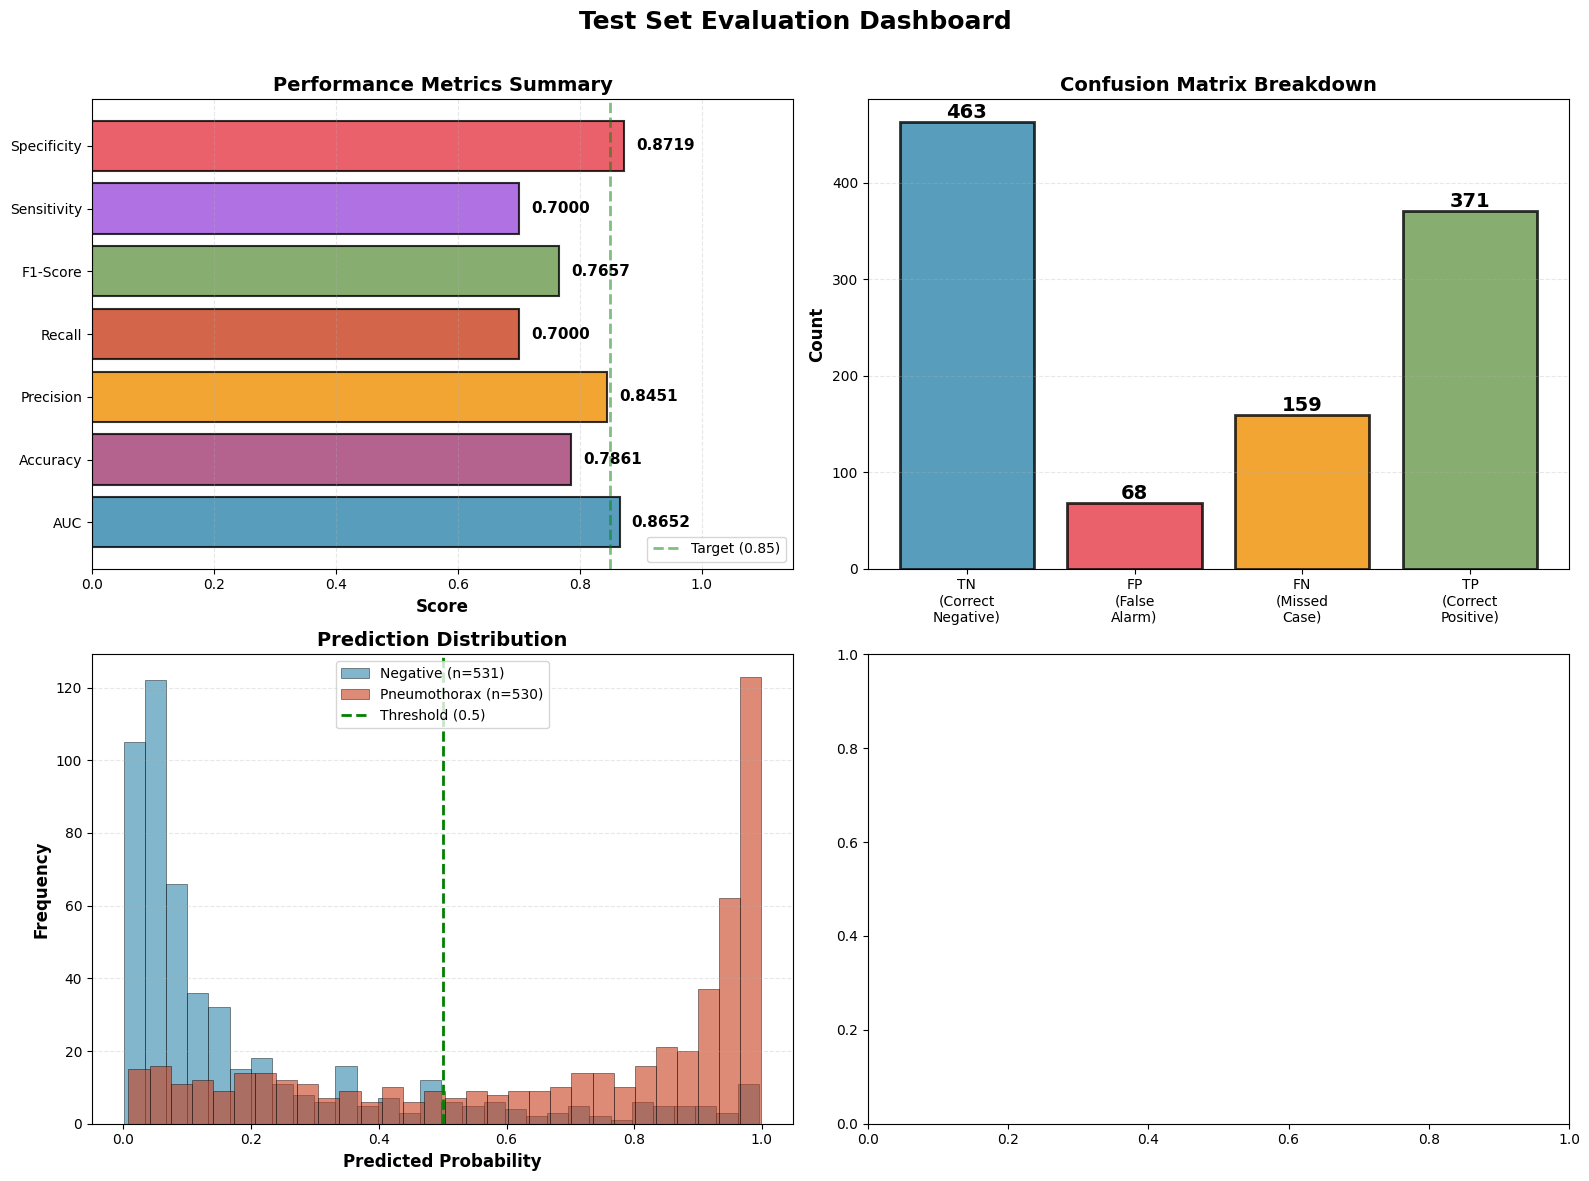

✅ Evaluation dashboard saved to: ./output/test_set_evaluation_dashboard.png


In [13]:
# ============================================================================
# COMPREHENSIVE METRICS DASHBOARD
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ============================================================================
# 1. Metrics Bar Chart
# ============================================================================
ax1 = axes[0, 0]
metrics_names = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 
                 'Sensitivity', 'Specificity']
metrics_values = [auc_score, accuracy, precision, recall, f1, 
                  sensitivity, specificity]
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#9D4EDD', '#E63946']

bars = ax1.barh(metrics_names, metrics_values, color=colors, alpha=0.8, 
                edgecolor='black', linewidth=1.5)

for i, (bar, value) in enumerate(zip(bars, metrics_values)):
    ax1.text(value + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{value:.4f}',
            ha='left', va='center', fontsize=11, fontweight='bold')

ax1.set_xlim([0, 1.15])
ax1.set_xlabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Performance Metrics Summary', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.axvline(x=0.85, color='green', linestyle='--', linewidth=2, alpha=0.5, 
           label='Target (0.85)')
ax1.legend(loc='lower right')

# ============================================================================
# 2. Confusion Matrix Counts
# ============================================================================
ax2 = axes[0, 1]
categories = ['TN\n(Correct\nNegative)', 'FP\n(False\nAlarm)', 
              'FN\n(Missed\nCase)', 'TP\n(Correct\nPositive)']
counts = [tn, fp, fn, tp]
colors_cm = ['#2E86AB', '#E63946', '#F18F01', '#6A994E']

bars = ax2.bar(categories, counts, color=colors_cm, alpha=0.8, 
               edgecolor='black', linewidth=2)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('Confusion Matrix Breakdown', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# ============================================================================
# 4. Probability Distribution
# ============================================================================
ax4 = axes[1, 0]

y_pred_probs_negative = y_pred_probs[y_true == 0]
y_pred_probs_positive = y_pred_probs[y_true == 1]

ax4.hist(y_pred_probs_negative, bins=30, alpha=0.6, color='#2E86AB', 
         label=f'Negative (n={len(y_pred_probs_negative)})', 
         edgecolor='black', linewidth=0.5)
ax4.hist(y_pred_probs_positive, bins=30, alpha=0.6, color='#C73E1D', 
         label=f'Pneumothorax (n={len(y_pred_probs_positive)})', 
         edgecolor='black', linewidth=0.5)
ax4.axvline(x=0.5, color='green', linestyle='--', linewidth=2, 
           label='Threshold (0.5)')
ax4.set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax4.set_title('Prediction Distribution', fontsize=14, fontweight='bold')
ax4.legend(loc='upper center', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y', linestyle='--')

# ============================================================================
# Overall title
# ============================================================================
fig.suptitle('Test Set Evaluation Dashboard', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('./output/test_set_evaluation_dashboard.png', dpi=300, 
            bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Evaluation dashboard saved to: ./output/test_set_evaluation_dashboard.png")